In [1]:
import torch   
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

with_cuda = torch.cuda.is_available()
if with_cuda:
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from preprocessing import normalization, denormalization
import os
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import random_split, DataLoader, Dataset
from torch.amp import GradScaler
from torch.amp import autocast



In [2]:
def save_audio_original(path, spec, epoch):
    # Enregistrer le fichier audio
    audio_path = os.path.join(path + "\\son", f"audio_original.wav")
    spec_amp = librosa.db_to_amplitude(spec)
    signal = librosa.griffinlim(spec_amp, hop_length=512)
    sf.write(audio_path, signal, 22050)
         
    
def save_audio_reconstructed(path, spec, epoch):
    # Enregistrer le fichier audio
    audio_path = os.path.join(path + "\\son", f"audio_reconstruit{epoch}.wav")
    spec_amp = librosa.db_to_amplitude(spec)
    signal = librosa.griffinlim(spec_amp, hop_length=512)

    sf.write(audio_path, signal, 22050)

def save_image_original(path, image, epoch):
    # Enregistrer l'image
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(image, y_axis='log', x_axis='time')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"{image} : {epoch}")
    img_path = os.path.join(path + "\\images" , "images_original.png")
    plt.savefig(img_path)
    plt.close()

def save_image_reconstruit(path, image, epoch):
    # Enregistrer l'image
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(image, y_axis='log', x_axis='time')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"{image} : {epoch}")
    img_path = os.path.join(path + "\\images", f"images_reconstuites{epoch}.png")
    plt.savefig(img_path)
    plt.close()

In [3]:
class RNN_autoencoder(nn.Module):
    def __init__(self, input_dim=1025, hidden_dim=600, style_dim = 2, num_layers=1): #800 bien pour spec
        super(RNN_autoencoder, self).__init__()
        self.encoder = nn.RNN(input_dim, hidden_dim,  num_layers=num_layers , batch_first=True)
        self.decoder = nn.RNN(hidden_dim + style_dim , hidden_dim, num_layers=num_layers , batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, input_dim)        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
    def forward(self, x, style):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)
        latent, h_enc = self.encoder(x, h0) # latent: [batch, seq_len, hidden]
        latent = torch.cat( [latent, style.unsqueeze(1).repeat(1, latent.size(1), 1)], dim=2)  # Concatenate style vector
        output, _ = self.decoder(latent, h_enc)
        output2 = self.output_layer(output)  # final projection
        return output2
    
    def changement_style(self, x, style):
        nouveau_style = (style - 1) * (-1) 
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)
        latent, h_enc = self.encoder(x, h0) # latent: [batch, seq_len, hidden]
        latent = torch.cat( [latent, nouveau_style.unsqueeze(1).repeat(1, latent.size(1), 1)], dim=2)  # Concatenate style vector
        output, _ = self.decoder(latent, h_enc)
        output2 = self.output_layer(output)  # final projection
        return output2

In [4]:
class GRU_autoencoder(nn.Module):
    def __init__(self, input_dim=1025, hidden_dim=1025, style_dim = 2, num_layers=1, bottle_dim = 1025): 
        super(GRU_autoencoder, self).__init__()
        self.encoder = nn.GRU(input_dim, hidden_dim,  num_layers=num_layers , batch_first=True)
        self.bottleneck = nn.Linear(hidden_dim, bottle_dim)
        self.decoder = nn.GRU(bottle_dim + style_dim , hidden_dim, num_layers=num_layers , batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, input_dim)        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
    def forward(self, x, style):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)
        latent, h_enc = self.encoder(x, h0) # latent: [batch, seq_len, hidden]
        latent = self.bottleneck(latent)  # bottleneck
        latent = torch.cat( [latent, style.unsqueeze(1).repeat(1, latent.size(1), 1)], dim=2)  # Concatenate style vector
        output, _ = self.decoder(latent, h_enc)
        output2 = self.output_layer(output)  # final projection
        return output2
    
    def changement_style(self, x, style):
        nouveau_style = (style - 1) * (-1) 
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)
        latent, h_enc = self.encoder(x, h0) # latent: [batch, seq_len, hidden]
        latent = self.bottleneck(latent)  # bottleneck
        latent = torch.cat( [latent, nouveau_style.unsqueeze(1).repeat(1, latent.size(1), 1)], dim=2)  # Concatenate style vector
        output, _ = self.decoder(latent, h_enc)
        output2 = self.output_layer(output)  # final projection
        return output2

In [5]:
class TransformerAutoencoder(nn.Module):
    def __init__(self, input_dim=1025, d_model=512, nhead=8, num_layers=4, style_dim=2):
        super().__init__()
        
        self.input_linear = nn.Linear(input_dim, d_model)   # Pour encoder 1025 → 512
        self.style_linear = nn.Linear(style_dim, d_model)   # Pour injecter le style
        
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        self.output_linear = nn.Linear(d_model, input_dim)

    def forward(self, x, style):
        """
        x: (batch, seq_len, input_dim)
        style: (batch, style_dim)
        """
        x = self.input_linear(x)  # (batch, seq_len, d_model)
        x = x.permute(1, 0, 2)     # transformer expects (seq_len, batch, d_model)

        # Style injection (broadcast style to each timestep)
        style_vec = self.style_linear(style).unsqueeze(1)  # (batch, 1, d_model)
        style_seq = style_vec.repeat(1, x.shape[0], 1).permute(1, 0, 2)

        encoded = self.encoder(x)
        decoded = self.decoder(style_seq, encoded)
        decoded = decoded.permute(1, 0, 2)
        return self.output_linear(decoded)


In [6]:
class FiLM(nn.Module):
    def __init__(self, hidden_dim, style_dim):
        super().__init__()
        self.gamma = nn.Linear(style_dim, hidden_dim)
        self.beta = nn.Linear(style_dim, hidden_dim)

    def forward(self, hidden, style):
        gamma = self.gamma(style).unsqueeze(1)  # (B, 1, H)
        beta = self.beta(style).unsqueeze(1)
        return hidden * gamma + beta

In [7]:
class GRU_autoencoder_film(nn.Module):
    def __init__(self, input_dim=1025, hidden_dim=1025, style_dim=2, num_layers=1, bottle_dim=1025): 
        super(GRU_autoencoder_film, self).__init__()
        self.encoder = nn.GRU(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.bottleneck = nn.Linear(hidden_dim, bottle_dim)
        self.decoder = nn.GRU(bottle_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.film = FiLM(hidden_dim, style_dim)
        self.output_layer = nn.Linear(hidden_dim, input_dim)        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

    def forward(self, x, style):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)
        latent, h_enc = self.encoder(x, h0)  # [B, T, H]
        latent = self.bottleneck(latent)     # [B, T, D]
        modulated = self.film(latent, style) # [B, T, H]
        output, _ = self.decoder(modulated, h_enc)
        output2 = self.output_layer(output)
        return output2

    def changement_style(self, x, style):
        nouveau_style = (style - 1) * (-1)
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)
        latent, h_enc = self.encoder(x, h0)
        latent = self.bottleneck(latent)
        modulated = self.film(latent, nouveau_style)
        output, _ = self.decoder(modulated, h_enc)
        output2 = self.output_layer(output)
        return output2


In [ ]:
class LSTM_autoencoder(nn.Module):
    def __init__(self, input_dim=1025, hidden_dim=600, style_dim = 2): #800 bien pour spec
        super(LSTM_autoencoder, self).__init__()
        self.encoder = nn.LSTM(input_dim,  hidden_dim,
                       num_layers=2,
                       batch_first=True,
                       bidirectional=True)
        
        self.decoder = nn.LSTM(hidden_dim*2 + style_dim, hidden_dim,
                       num_layers=2,
                       batch_first=True)
        
        self.output_layer = nn.Linear(hidden_dim, input_dim)        
        self.hidden_dim = hidden_dim
        
    def forward(self, x, style):
        
        B, T, _ = x.size()

        # Initialisation des états (h, c) pour 2 couches * 2 directions
        h0 = torch.zeros(2*2, B, self.hidden_dim, device=x.device)  # num_layers*directions
        c0 = torch.zeros(2*2, B, self.hidden_dim, device=x.device)

        # Encodeur bidirectionnel
        # enc_out: [B, T, hidden_dim*2]
        # (h_n, c_n) ont shape [num_layers*2, B, hidden_dim]
        enc_out, (h_n, c_n) = self.encoder(x, (h0, c0))

        # Concaténation du style sur chaque pas de temps
        # style: [B, style_dim] -> [B, T, style_dim]
        style_exp = style.unsqueeze(1).expand(-1, T, -1)
        dec_in    = torch.cat([enc_out, style_exp], dim=2)  # [B, T, hidden_dim*2+style_dim]

        # Décodage (unidirectionnel)
        # On réutilise seulement les derniers états de l'encodeur comme init pour le décodeur
        # On prend h_n[-1] et c_n[-1] (de la dernière couche, direction finale)
        h_dec0 = h_n.view(2, 2, B, self.hidden_dim)[-1]  # shape: [2, B, hidden_dim]
        c_dec0 = c_n.view(2, 2, B, self.hidden_dim)[-1]  # idem
        dec_out, _ = self.decoder(dec_in, (h_dec0, c_dec0))
        
        # Projection finale
        out = self.output_layer(dec_out)  # [B, T, input_dim]
        return out

In [ ]:
class transformer(nn.Module):
    def __init__(self, input_dim=1025, hidden_dim=600, style_dim = 2): #800 bien pour spec
        super(transformer, self).__init__()
        self.encoder = nn.TransformerEncoderLayer(d_model=input_dim, nhead=5)
        self.decoder = nn.TransformerDecoderLayer(d_model=input_dim, nhead=5)
        self.output_layer = nn.Linear(input_dim, input_dim)        
        self.hidden_dim = hidden_dim
        
    def forward(self, x, style):
        batch_size = x.size(0)
        h0 = torch.zeros(1, batch_size, self.hidden_dim).to(x.device)
        latent = self.encoder(x) # latent: [batch, seq_len, hidden]
        latent = torch.cat( [latent, style.unsqueeze(1).repeat(1, latent.size(1), 1)], dim=2)  # Concatenate style vector
        output = self.decoder(latent)
        output2 = self.output_layer(output)  # final projection
        return output2

In [8]:
def split_sequence(input_tensor, chunk_len=2000):# faut que 2000 soit un multiple de chunk_len
    # input_tensor: (batch, 1025, 2000)
    input_tensor = input_tensor.permute(0, 2, 1)  # (batch, time, freq) = (B, 2000, 1025)
    batch, total_len, feat = input_tensor.shape
    num_chunks = total_len // chunk_len

    input_tensor = input_tensor.contiguous().view(batch, num_chunks, chunk_len, feat)  
    return input_tensor, chunk_len # (batch*num_chunks, chunk_len, 1025) = (B*10, 200, 1025)


In [ ]:
def testeur(data_loader, model, device , epoch , loss_test, loss_affichage, minim, maxim):
    path = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\P2\\images_piano_to_chill"
    
    original, style = data_loader.dataset[12]
    original = original.unsqueeze(0).to(device)
    style = style.to(device)
   
    with torch.no_grad():
        
        # Reconstruction
        
        x_chunks, chunk_len = split_sequence(original)  
                    
        B, N, time, F = x_chunks.shape
        x_chunks = x_chunks.view(B * N, time, F)
        style_chunks = style.unsqueeze(1).repeat(1, N, 1).view(B * N, -1)
        
        reconstructed= model(x_chunks,style_chunks) # 120 200 1025
        reconstructed = reconstructed.view(B, N, chunk_len, 1025)        # (12, 10, 200, 1025)
        reconstructed = reconstructed.permute(0, 2, 1, 3)                # (12, 200, 10, 1025)
        reconstructed = reconstructed.reshape(B, N * chunk_len, 1025)    # (12, 2000, 1025)
        reconstructed = reconstructed.permute(0, 2, 1)                    # (12, 1025, 2000)

    original = original.squeeze(0).cpu().detach().numpy()
    reconstructed = reconstructed.squeeze(0).cpu().detach().numpy()


    original = denormalization(original, minim, maxim)

    reconstructed2 = denormalization(reconstructed, minim, maxim)
    
    save_audio_original(path, original, epoch)
    save_audio_reconstructed(path, reconstructed2, epoch)
    save_image_original(path, original, epoch)
    save_image_reconstruit(path, reconstructed2, epoch)
    
    if epoch > 0 : 
        plt.figure(figsize=(10, 4))
        train = list(range(len(loss_affichage)))         # [0, 1, 2, ..., 49]
        test = list(range(0, epoch+1 , 10))   # [0, 10, 20, 30, 40]
   
        # 2. Les courbes
        plt.plot(train, loss_affichage, label='Train Loss', color='blue')
        plt.plot(test, loss_test, label='Test Loss', color='orange', marker='o')

        # 3. Habillage
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Train vs Test Loss')
        plt.legend()
        plt.grid(True)

        # 4. Sauvegarde
        plt.savefig(os.path.join(path + "\\loss", f"loss_comparaison_{epoch}epochs.png"))
        plt.close()

    
    if epoch > 10 : 
        loss__test_tronque = loss_test[1:]
        loss_affichage_tronque = loss_affichage[10:]
        plt.figure(figsize=(10, 4))
        train = list(range(len(loss_affichage_tronque)))         # [0, 1, 2, ..., 49]
        test = list(range(0, epoch, 10))   # [0, 10, 20, 30, 40]

        # 2. Les courbes
        plt.plot(train, loss_affichage_tronque, label='Train Loss', color='blue')
        plt.plot(test, loss__test_tronque, label='Test Loss', color='orange', marker='o')

        # 3. Habillage
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Train vs Test Loss')
        plt.legend()
        plt.grid(True)

        # 4. Sauvegarde
        plt.savefig(os.path.join(path + "\\loss", f"loss_comparaison_tronque.png"))
        plt.close()
        
    
    

In [10]:
def one_hot(label):
    if label == "Chill":
        return torch.tensor([0., 1.])
    elif label == "Classique":
        return torch.tensor([1., 0.])
    else:
        raise ValueError("Unknown label: " + label)


In [11]:
class SpectrogramDataset(Dataset):
    def __init__(self, spec_path, minim, maxim , label_str = None):
        self.file_paths = [os.path.join(spec_path, f)
                           for f in os.listdir(spec_path) if f.endswith('.npy')]
        self.minim = minim
        self.maxim = maxim
        self.label_tens = one_hot(label_str)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        spec = np.load(self.file_paths[idx])
        spec_tensor = torch.from_numpy(spec).float()
        spec_norm = (spec_tensor - self.minim) / (self.maxim - self.minim)
        style_vec = self.label_tens
        return spec_norm, style_vec

def get_data(spec_path, minim, maxim, split_ratio=0.8, label = None):
    dataset = SpectrogramDataset(spec_path, minim, maxim , label_str = label)
    train_size = int(split_ratio * len(dataset))
    test_size = len(dataset) - train_size

    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
    
    return train_dataset, test_dataset



In [ ]:
def train_model_avec_chunks(data_loader,test_loader, model, criterion, optimizer, nepochs, device, minim ,maxim, chunk_len=2000, scheduler=None):

    scaler = GradScaler(device='cuda')
    loss_affichage = []
    max = np.inf
    loss_test = []

    for epoch in range(nepochs):
        train_loss = 0
        model.train()
        for batch_idx, (input_, style) in enumerate(tqdm(data_loader, desc=f"Epoch {epoch}")):
            
            input_ = input_.to(device)  # shape: (batch, 1025, 2000)
            style = style.to(device)  # shape: (batch, 2)
            
            # Découpage en petits morceaux
            
            x_chunks, chunk_len = split_sequence(input_, chunk_len=chunk_len)  # (B, num_chunk, chunk_len, 1025) me coupe la musique en plein de morceaux de 200
            B, N, time, F = x_chunks.shape
            x_chunks = x_chunks.view(B * N, time, F)
            style_chunks = style.unsqueeze(1).repeat(1, N, 1).view(B * N, -1)
            
            optimizer.zero_grad()
            
            with autocast('cuda'):  # 👈 Ici, on fait tout en float16 sauf exceptions

                reconstruction = model(x_chunks,style_chunks)
                
                loss = criterion(reconstruction, x_chunks)
    
            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)  # Obligatoire avant clip avec AMP
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.detach().cpu().item()
            
                   
        avg_loss = train_loss / len(data_loader)
        
        if max > avg_loss:
                max = avg_loss 
                torch.save(model.state_dict(), "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\P2\\images_piano_to_chill\\modele\\best_modele.pth")

        loss_affichage.append(avg_loss)	
        print(f"Epoch {epoch}: Training loss = {avg_loss:.6f}")
        
        if scheduler is not None:
            scheduler.step(avg_loss)
        
        if epoch % 10 == 0:
            test_loss = 0
            model.eval()
            
            with torch.no_grad():
                for batch_idx, (input_,style) in enumerate(test_loader):
                    input_ = input_.to(device)
                    style = style.to(device)
                    x_chunks, chunk_len = split_sequence(input_, chunk_len=chunk_len)
                    
                    B, N, time, F = x_chunks.shape
                    x_chunks = x_chunks.view(B * N, time, F)
                    style_chunks = style.unsqueeze(1).repeat(1, N, 1).view(B * N, -1)
            
                    recon = model(x_chunks,style_chunks)
                    loss= criterion(recon, x_chunks)
                    test_loss += loss.detach().cpu().item()
                loss_test.append(test_loss/len(test_loader))
                print(f"Test loss = {test_loss/len(test_loader):.6f}")
                
        if epoch % 10 == 0:
            testeur(test_loader, model, device , epoch , loss_test, loss_affichage, minim, maxim)

In [13]:
def loss_fn(input, target):
    input = torch.log1p(input + 1e-6)
    target = torch.log1p(target + 1e-6)
    return F.mse_loss(input, target)

In [ ]:
spec_piano_path = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\P2\\spec_piano"
spec_hard_path = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\P2\\spec_different"


max_value = float('-inf') 
min_value = float('inf') 

for f in os.listdir(spec_hard_path):
    if f.endswith('.npy'):
        file_path = os.path.join(spec_hard_path, f)
        data = np.load(file_path)
        max_value = max(max_value, data.max())  # Update max_value if a larger value is found
        min_value = min(min_value, data.min())  # Update min_value if a smaller value is found
        
for f in os.listdir(spec_piano_path):
    if f.endswith('.npy'):
        file_path = os.path.join(spec_piano_path, f)
        data = np.load(file_path)
        max_value = max(max_value, data.max())  # Update max_value if a larger value is found
        min_value = min(min_value, data.min())  # Update min_value if a smaller value is found

In [15]:
#criterion = auraloss.freq.MultiResolutionSTFTLoss() # a tester e profondeur
#criterion = nn.MSELoss()  #avant
criterion = loss_fn  # Utiliser la classe personnalisée
model = GRU_autoencoder_film().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0010) # 0.0011 bien pour spec
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)
    
train_dataset_chill, test_dataset_chill = get_data(spec_hard_path, min_value, max_value, label = "Chill")
train_dataset_piano, test_dataset_piano = get_data(spec_piano_path, min_value, max_value, label = "Classique")
train_dataset = torch.utils.data.ConcatDataset([train_dataset_chill, train_dataset_piano])
train_loader = DataLoader(train_dataset, batch_size=12, shuffle=True)
test_dataset = torch.utils.data.ConcatDataset([test_dataset_chill, test_dataset_piano])
test_loader = DataLoader(test_dataset, batch_size=12, shuffle=False)

chunk_len = 2000
train_model_avec_chunks(train_loader, test_loader, model, criterion, optimizer, nepochs=31, device=device, minim=min_value, maxim=max_value, chunk_len=chunk_len, scheduler=scheduler)


c:\Users\gabri\anaconda3\envs\gab\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 0: 100%|██████████| 19/19 [00:13<00:00,  1.39it/s]


Epoch 0: Training loss = 0.024679
Test loss = 0.004388


Epoch 1: 100%|██████████| 19/19 [00:11<00:00,  1.62it/s]


Epoch 1: Training loss = 0.003579


Epoch 2: 100%|██████████| 19/19 [00:11<00:00,  1.65it/s]


...

Epoch 28: Training loss = 0.001466


Epoch 29: 100%|██████████| 19/19 [00:18<00:00,  1.02it/s]


Epoch 29: Training loss = 0.001436


Epoch 30: 100%|██████████| 19/19 [00:19<00:00,  1.01s/it]


Epoch 30: Training loss = 0.001454
Test loss = 0.001398


In [16]:
def save_audio_original_style(path, spec):
    # Enregistrer le fichier audio
    audio_path = os.path.join(path , f"audio_original.wav")
    spec_amp = librosa.db_to_amplitude(spec)
    signal = librosa.griffinlim(spec_amp, hop_length=512)
    sf.write(audio_path, signal, 22050)
         
    
def save_audio_reconstructed_style(path, spec):
    # Enregistrer le fichier audio
    audio_path = os.path.join(path , f"audio_reconstruit.wav")
    spec_amp = librosa.db_to_amplitude(spec)
    signal = librosa.griffinlim(spec_amp, hop_length=512)

    sf.write(audio_path, signal, 22050)

def save_image_original_style(path, image):
    # Enregistrer l'image
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(image, y_axis='log', x_axis='time')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"{image} :")
    img_path = os.path.join(path , "images_original.png")
    plt.savefig(img_path)
    plt.close()

def save_image_reconstruit_style(path, image):
    # Enregistrer l'image
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(image, y_axis='log', x_axis='time')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"{image} : 2 ")
    img_path = os.path.join(path , f"images_reconstuites.png")
    plt.savefig(img_path)
    plt.close()

In [ ]:
def test_de_changement_de_style(data_loader, model, minim, maxim):
    path = "C:\\Users\\gabri\\Desktop\\dauphine\\L3\\S2\\Deep_learning\\Parties\\P2\\images_piano_to_chill\\change_style"
    
    original, style = data_loader.dataset[12]
    original = original.unsqueeze(0).to(device)
    style = style.to(device)
    
    with torch.no_grad():
        
        # Reconstruction
        
        x_chunks, chunk_len = split_sequence(original)  
                    
        B, N, time, F = x_chunks.shape
        x_chunks = x_chunks.view(B * N, time, F)
        style_chunks = style.unsqueeze(1).repeat(1, N, 1).view(B * N, -1)
        
        reconstructed= model.changement_style(x_chunks,style_chunks) # 120 200 1025
        reconstructed = reconstructed.view(B, N, chunk_len, 1025)        # (12, 10, 200, 1025)
        reconstructed = reconstructed.permute(0, 2, 1, 3)                # (12, 200, 10, 1025)
        reconstructed = reconstructed.reshape(B, N * chunk_len, 1025)    # (12, 2000, 1025)
        reconstructed = reconstructed.permute(0, 2, 1)                    # (12, 1025, 2000)

    original = original.squeeze(0).cpu().detach().numpy()
    reconstructed = reconstructed.squeeze(0).cpu().detach().numpy()


    original = denormalization(original, minim, maxim)

    reconstructed2 = denormalization(reconstructed, minim, maxim)
    
    save_audio_original_style(path, original)
    save_audio_reconstructed_style(path, reconstructed2)
    save_image_original_style(path, original)
    save_image_reconstruit_style(path, reconstructed2)

        
    
test_de_changement_de_style(test_loader, model, min_value, max_value)


    

2.4736666679382324


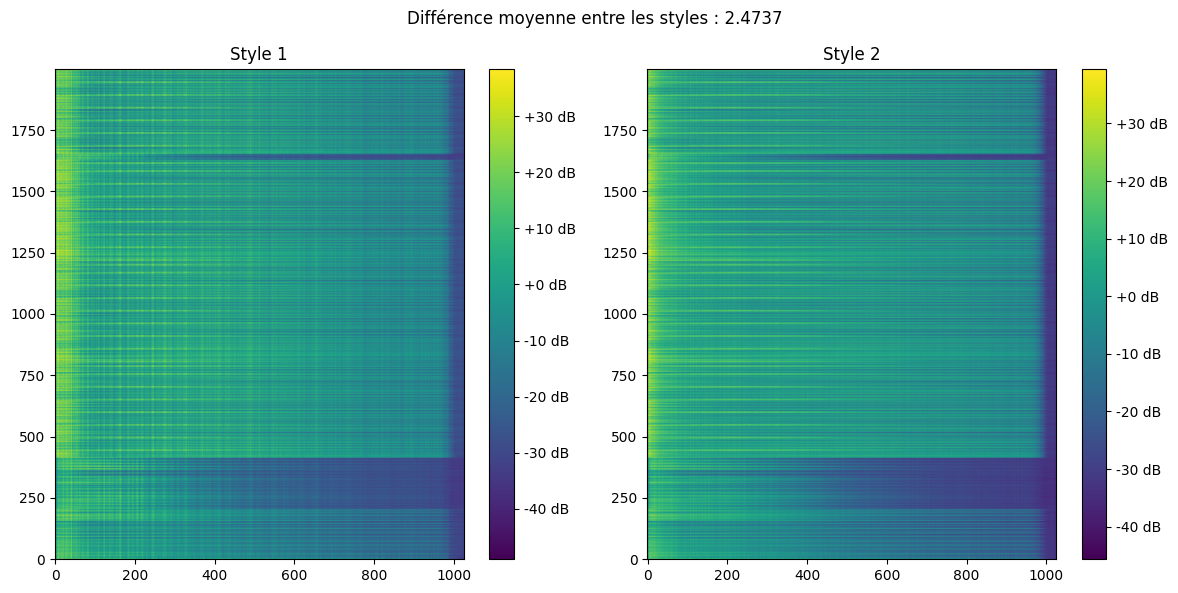

In [18]:
original, style = test_loader.dataset[12]
original = original.unsqueeze(0).to(device)
x_chunks, chunk_len = split_sequence(original)  
B, N, time, F = x_chunks.shape
x = x_chunks.view(B * N, time, F)

output_style_1 = model(x, style=torch.tensor([[1., 0.]] * x.size(0)).to(x.device))
output_style_2 = model(x, style=torch.tensor([[0., 1.]] * x.size(0)).to(x.device))
output_style_1 = denormalization(output_style_1, min_value, max_value)
output_style_2 = denormalization(output_style_2, min_value, max_value)
diff = torch.mean(torch.abs(output_style_1 - output_style_2))
print(diff.item())
# Conversion en numpy pour affichage
output_style_1_np = output_style_1.squeeze(0).cpu().detach().numpy()
output_style_2_np = output_style_2.squeeze(0).cpu().detach().numpy()

# Création des subplots
plt.figure(figsize=(12, 6))

# Style 1
plt.subplot(1, 2, 1)
plt.title("Style 1")
plt.imshow(output_style_1_np, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(format='%+2.0f dB')

# Style 2
plt.subplot(1, 2, 2)
plt.title("Style 2")
plt.imshow(output_style_2_np, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(format='%+2.0f dB')

# Affichage
plt.suptitle(f"Différence moyenne entre les styles : {diff.item():.4f}")
plt.tight_layout()
plt.show()